In [1]:
from podio.root_io import Reader
import numpy as np
from RecoUtils import decodeRawHits, vec3d2mat
from Hit3DBuilder import buildHitPairs


compton_event_path = "./compton_digi.root"
reader = Reader(compton_event_path)

events = reader.get("events")

event = events[1]
traj_points = event.get("TpcSimHits")
plain_hits = event.get("TpcHits")
wave_hits = event.get("TpcWaveformHits")

Module libc not found.


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


In [2]:
charges = wave_hits.charge()
times = wave_hits.time()
cells = wave_hits.cellID()

In [3]:
from megat import getIdConverter, getTpcDecoder

converter = getIdConverter()
decoder = getTpcDecoder()

cellID_pos_mapper = np.frompyfunc(lambda id: converter.position(id), 1, 1)
cellID_layer_mapper = np.frompyfunc(lambda id: decoder.get(id, "layer"), 1, 1)

trajs = vec3d2mat(traj_points.position())
poss = vec3d2mat(cellID_pos_mapper(cells))
layers = cellID_layer_mapper(cells)

Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


Prepare for plotting data.

In [9]:
import pandas as pd
from datar.all import f, mutate, if_else, filter_, select, bind_rows

df_traj = pd.DataFrame(trajs, columns=["x", "y", "z"])
df_traj = mutate(df_traj, edep=np.array(traj_points.EDep()))

df_wave = pd.DataFrame(poss, columns=["x", "y", "z"])
df_wave = mutate(df_wave, layer=layers, edep=np.array(charges), time=np.array(times))
df_wave = mutate(df_wave, z=f.z - f.time / 1000 * 60)  # type: ignore
df_wave = mutate(df_wave, xy=if_else(f.layer == 0, f.x, f.y))



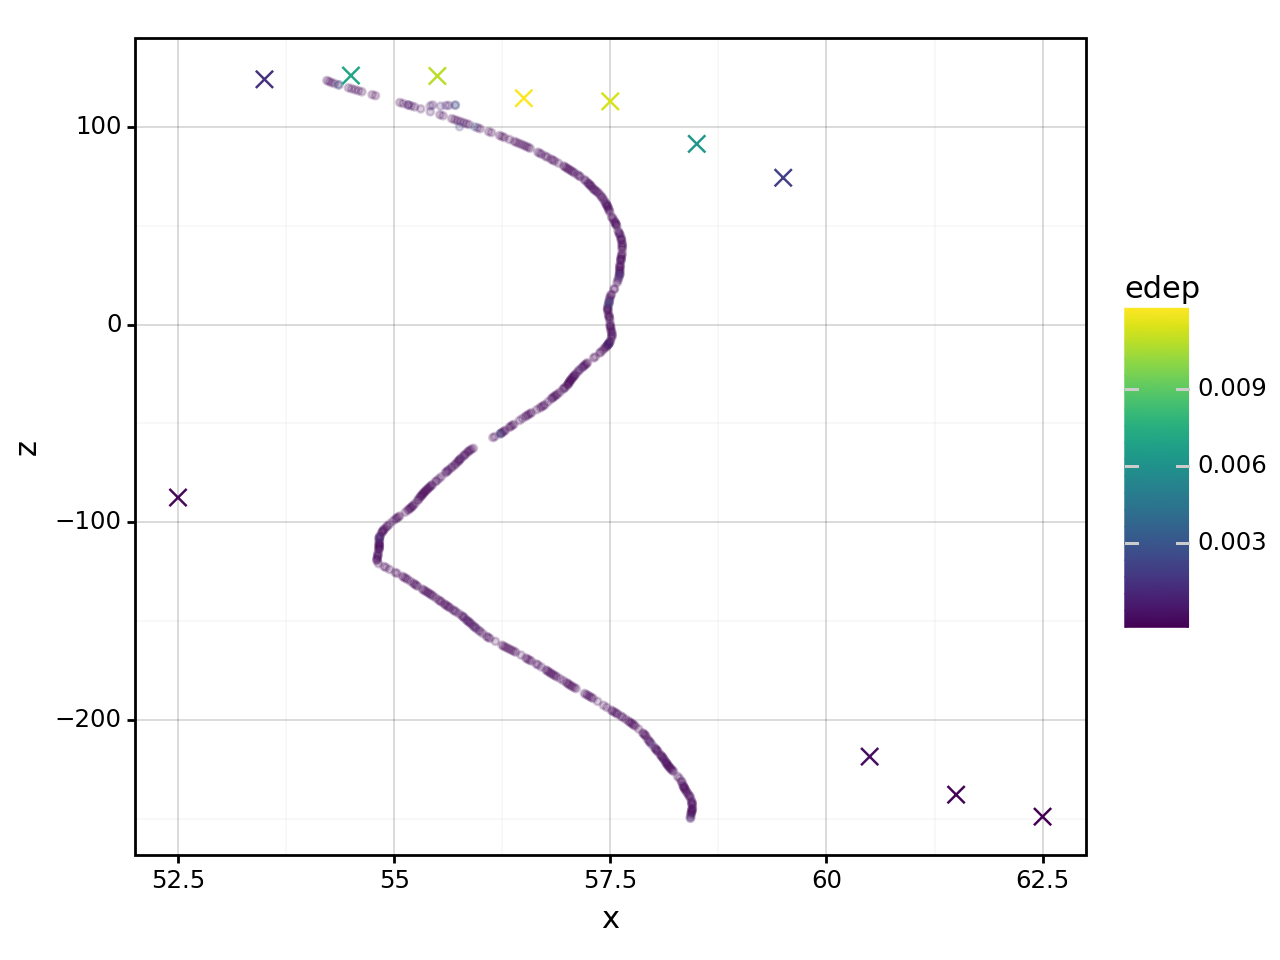

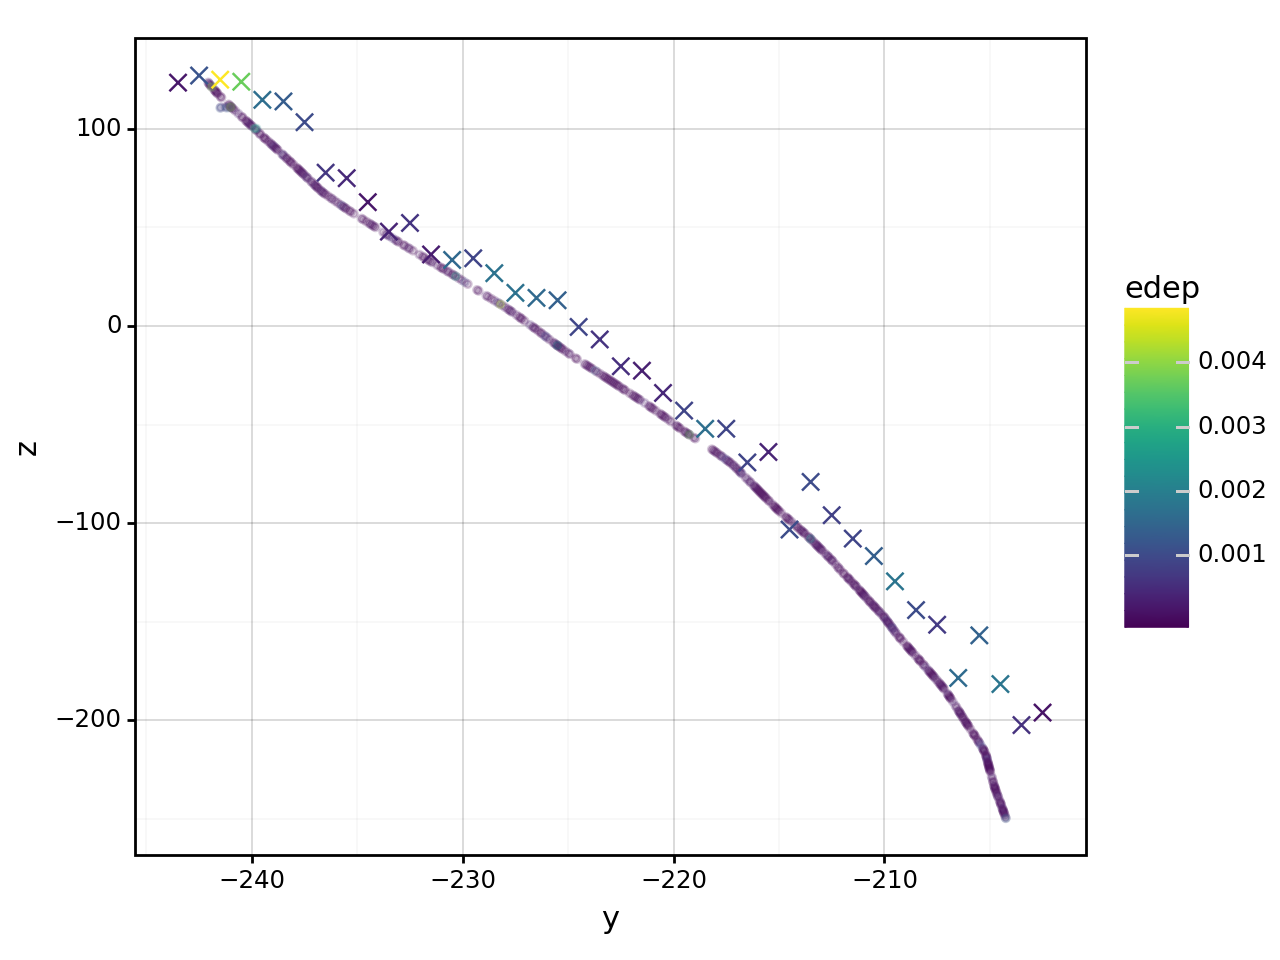

In [16]:
from plotnine import (
    aes,
    facet_wrap,
    geom_point,
    scale_x_continuous,
    theme_linedraw,
    theme_minimal,
    theme_set,
)
from plotnine.ggplot import ggplot

theme_set(theme_linedraw())

p1 = (
    df_wave
    >> filter_(f.layer == 0)
    >> ggplot(aes(x="x", y="z", color="edep"))  # type: ignore
    + geom_point(data=df_traj, alpha=0.2, size=1)
    + geom_point(shape="x", size=3)
)

p2 = (
    df_wave
    >> filter_(f.layer != 0)
    >> ggplot(aes(x="y", y="z", color="edep"))  # type: ignore
    + geom_point(data=df_traj, alpha=0.2, size=1)
    + geom_point(shape="x", size=3)
)

print(p1, p2)